Configuration for Python Code

In [19]:
import os
import pandas as pd
import numpy as np
import statistics

# For Visualisation:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
#PIECHART - RESULABLE CODE
def plot_pie_chart(data, column_name):
    """
    Parameters:
    - data: DataFrame
    - column_name: str, the column for which to plot the pie chart
    """
    # Count the occurrences of each value in the specified column
    counts = data[column_name].value_counts()

    # Plot a pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=50)
    plt.title(f'Distribution of {column_name} Values')
    plt.show()

## Initialise Datasets
Load them from local machine

In [21]:
path = r"C:\Users\uma shanker\Downloads\data"
os.chdir(path)
FolderContents=os.listdir()
for i in FolderContents:
    print(i)

Airlines_RoundTrip_Analysis.csv
Airport_Codes.csv
Flights.csv
Tickets.csv


# 📥 Load Datasets for Analysis

This section loads the necessary datasets into pandas DataFrames for further analysis.

---

## ✈️ 1. Load Airport Codes Data
- Contains metadata for airports, including type, location, and identifiers.
- We'll use this to filter for US-based medium and large airports.

In [22]:
df_Airport_Codes=pd.read_csv("Airport_Codes.csv")

In [23]:
print(df_Airport_Codes.head())

            TYPE                                NAME  ELEVATION_FT CONTINENT  \
0       heliport                   Total Rf Heliport          11.0       NaN   
1  small_airport                Aero B Ranch Airport        3435.0       NaN   
2  small_airport                        Lowell Field         450.0       NaN   
3  small_airport                        Epps Airpark         820.0       NaN   
4         closed  Newport Hospital & Clinic Heliport         237.0       NaN   

  ISO_COUNTRY  MUNICIPALITY IATA_CODE                            COORDINATES  
0          US      Bensalem       NaN     -74.93360137939453, 40.07080078125  
1          US         Leoti       NaN                 -101.473911, 38.704022  
2          US  Anchor Point       NaN            -151.695999146, 59.94919968  
3          US       Harvest       NaN  -86.77030181884766, 34.86479949951172  
4          US       Newport       NaN                    -91.254898, 35.6087  


## 🎫 2. Load Tickets Data

This dataset contains ticket-level information for domestic US flights during Q1 2019.

Key features:
- `ORIGIN`, `DESTINATION`: Airport codes for the flight path.
- `PASSENGERS`: Number of passengers per route.
- `ITIN_FARE`: Total fare collected for the itinerary.

These fields are essential for calculating **total revenue** and estimating **profitability per route**.


In [24]:
df_Tickets=pd.read_csv("Tickets.csv")

In [25]:
df_Tickets.head(5)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA
4,201912723509,2019,1,ABI,US,TX,Texas,0.0,MQ,1.0,309.0,MGM


## ✈️ 3. Load Flights Data

This dataset contains detailed flight-level information including delays, distance, cancellation status, and more.

Key features:
- `ORIGIN`, `DESTINATION`: Airport codes to identify the route.
- `DEP_DELAY`, `ARR_DELAY`: Departure and arrival delays (in minutes).
- `CANCELLED`: Indicates if the flight was canceled (1 = Yes, 0 = No).
- `AIR_TIME`, `DISTANCE`: Used to analyze operational efficiency and cost.
- `OCCUPANCY_RATE`: Estimated load factor of each flight.

This data is essential for:
- Identifying busy routes (excluding cancelled flights)
- Delay analysis for punctuality
- Estimating operational costs

In [26]:
df_Flights = pd.read_csv("Flights.csv", low_memory=False)  


In [27]:
 print(df_Flights.head())  

      FL_DATE OP_CARRIER TAIL_NUM OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID ORIGIN  \
0  2019-03-02         WN   N955WN              4591              14635    RSW   
1  2019-03-02         WN   N8686A              3231              14635    RSW   
2  2019-03-02         WN   N201LV              3383              14635    RSW   
3  2019-03-02         WN   N413WN              5498              14635    RSW   
4  2019-03-02         WN   N7832A              6933              14635    RSW   

  ORIGIN_CITY_NAME  DEST_AIRPORT_ID DESTINATION DEST_CITY_NAME  DEP_DELAY  \
0   Fort Myers, FL            11042         CLE  Cleveland, OH       -8.0   
1   Fort Myers, FL            11066         CMH   Columbus, OH        1.0   
2   Fort Myers, FL            11066         CMH   Columbus, OH        0.0   
3   Fort Myers, FL            11066         CMH   Columbus, OH       11.0   
4   Fort Myers, FL            11259         DAL     Dallas, TX        0.0   

   ARR_DELAY  CANCELLED AIR_TIME DISTANCE  OCCUPAN

In [28]:
df_Flights.head(5)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62


# ✈️ Airlines Data Cleansing

This section outlines the steps taken to clean and prepare the airlines dataset for further analysis.

---

### 1. ✅ Checking the Data Types
- Verify the data types of each column.
- Ensure numeric fields (e.g., latitude, longitude) are properly typed.
- Categorical fields such as `type`, `iso_country` should be strings or categories.

```python
airports.dtypes


In [29]:
df_Airport_Codes.dtypes

TYPE             object
NAME             object
ELEVATION_FT    float64
CONTINENT        object
ISO_COUNTRY      object
MUNICIPALITY     object
IATA_CODE        object
COORDINATES      object
dtype: object

### 2.🧹 Removing Duplicate Rows

Duplicate entries can skew analysis and lead to incorrect insights.  
We'll identify and remove any duplicate rows to ensure data quality and consistency.


In [30]:
df_Airport_Codes[df_Airport_Codes.duplicated()]

,TYPE,NAME,ELEVATION_FT,CONTINENT,ISO_COUNTRY,MUNICIPALITY,IATA_CODE,COORDINATES
11859,small_airport,Utai Airstrip,707.0,OC,PG,Utai,NaN,"141.5868, -3.386"
15123,seaplane_base,Morrison Lake Seaplane Base,716.0,NaN,CA,Gravenhurst,NaN,"-79.461, 44.8705"
15124,small_airport,Martin's Landing,1115.0,NaN,CA,Thunder Bay,NaN,"-89.543002, 48.2936"
17419,closed,BÃ¶blingen Flugfeld,NaN,EU,DE,BÃ¶blingen,PHM,"8.996193, 48.689544"
20106,large_airport,OR Tambo International Airport,5558.0,AF,ZA,Johannesburg,JNB,"28.246, -26.1392"
...,...,...,...,...,...,...,...,...
49398,closed,Amchitka Army Airfield,215.0,NaN,US,Amchitka Island,AHT,"179.259166667, 51.3777777778"
49478,closed,Montana ARNG Heliport,3649.0,NaN,US,Billings,NaN,"-108.566666667, 45.805"
51591,small_airport,Basanth Nagar Airport,670.0,AS,IN,Ramagundam,RMD,"79.3923, 18.701"
53221,small_airport,Bombala Airport,2415.0,OC,AU,NaN,NaN,"149.18200683594, -36.904998779297"


In [31]:
# Count duplicates before dropping
print("Duplicate rows before:", df_Airport_Codes.duplicated().sum())

# Drop duplicates
df_Airport_Codes = df_Airport_Codes.drop_duplicates()

# Confirm removal
print("Duplicate rows after:", df_Airport_Codes.duplicated().sum())


Duplicate rows before: 101
Duplicate rows after: 0


### 3.🔍 Identifying Null Values

Detect columns with missing values.  
Decide whether to fill or drop these based on business requirements.


In [32]:
#checking number of null values in each column
df_Airport_Codes.isnull().sum()

TYPE                0
NAME                0
ELEVATION_FT     6931
CONTINENT       27838
ISO_COUNTRY       247
MUNICIPALITY     5704
IATA_CODE       46093
COORDINATES         0
dtype: int64

### 4.🇺🇸 Filtering for United States Only

Filter dataset to include only entries where `iso_country == 'US'`.


In [33]:
# Keep only rows where ISO_COUNTRY is equal to 'US'
df_Airport_Codes = df_Airport_Codes[df_Airport_Codes['ISO_COUNTRY'] == 'US']
# Reset the index in place
df_Airport_Codes.reset_index(drop=True, inplace=True)

### 5.🏙️ Using Only Medium and Large Airports

Focus analysis on `medium_airport` and `large_airport` types.


In [34]:
# Filter rows where TYPE is 'medium_airport' or 'large_airport'
df_Airport_Codes = df_Airport_Codes[df_Airport_Codes['TYPE'].isin(['medium_airport', 'large_airport'])]

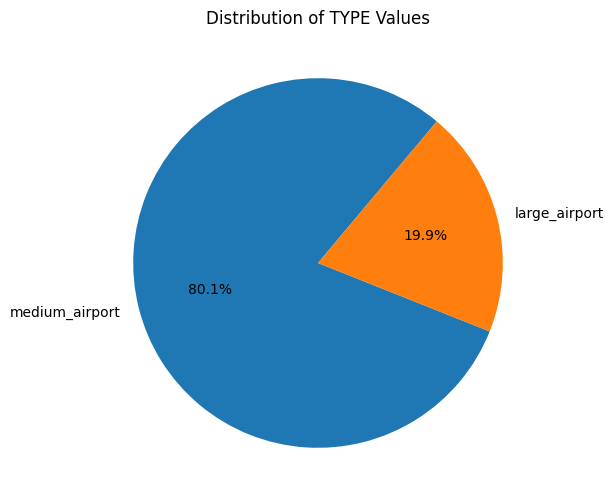

In [35]:
# Plotting the pie chart TYPE to visualize the relative percentages of larger and medium airports
# I can also plot the bar graph of the TYPE
# plot_bar_chart_with_percentages(airport_codes_clean, 'TYPE')
plot_pie_chart(df_Airport_Codes, 'TYPE')

Flights Data Clean up

As per the rrequiremnet ignore/remove the Cancelled files

In [36]:
# Keep only rows where 
df_Flights = df_Flights[df_Flights['CANCELLED'] == 0]
# Reset the index in place
df_Flights.reset_index(drop=True, inplace=True)

In [37]:
# Convert FL_DATE to datetime if not already
#df_Flights['FL_DATE'] = pd.to_datetime(df_Flights['FL_DATE'])

# Filter df_Flights to keep only rows with FL_DATE in Q1 2019 (Jan 1 to Mar 31)
df_Flights = df_Flights[(df_Flights['FL_DATE'] >= '2019-01-01') & (df_Flights['FL_DATE'] <= '2019-03-31')]


Transformations

### Creating Direction-Agnostic Routes  

#### ✅ Goal:
Create a consistent round trip identifier (e.g., 'JFK ORD' instead of 'ORD JFK') that treats 'JFK → ORD' and 'ORD → JFK' as the same route.

Loop through each flight record.  
Extract ORIGIN and DESTINATION, sort them alphabetically.  
Store as unique round-trip route pairs in a list.

In [38]:
Routes=[]
Route=[]
for i in range(df_Flights.shape[0]):
    Route=[df_Flights['ORIGIN'].iloc[i],df_Flights['DESTINATION'].iloc[i]]
    Routes.append(sorted(Route))

### ➕ Inserting 'Routes' Column  
Insert the computed `Routes` list as a new column.  
Place it at position 16 in the `df_Flights` DataFrame.  
Ensures route information is available for round-trip analysis.

In [39]:
df_Flights.insert(16, 'Routes', Routes)

### ✈️ Creating String-Based Round Trip Routes

- Combine each sorted origin-destination airport code pair into a single string.
- This string (e.g., "JFK ORD") represents a unique round trip route regardless of direction.
- Useful for aggregating metrics like round trip counts or profitability by route.
- The resulting `Routes` column will be used for further groupby and analysis.


In [40]:
Routes=[]
Route=[]
for i in range(df_Flights.shape[0]):
    Route=df_Flights['Routes'].iloc[i][0]+" "+df_Flights['Routes'].iloc[i][1]
    Routes.append(Route)

In [41]:
del df_Flights['Routes']

In [42]:
df_Flights.insert(16, 'Routes', Routes)

In [43]:
df_Flights.head(5)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,Routes
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97,CLE RSW
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55,CMH RSW
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91,CMH RSW
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67,CMH RSW
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62,DAL RSW


### Count Round Trip Flights per Route

- Group flights by origin, destination, and route to count number of flights.
- For each route (round trip), take the minimum flight count of both directions.
- Sort the routes by these minimum counts in descending order.
- Result shows busiest round trip routes based on actual round trips flown.

In [44]:
df_Flights_RoundTrip_Count = pd.DataFrame(
    df_Flights
        .groupby(['ORIGIN', 'DESTINATION', 'Routes'])['Routes']
        .count()
        .groupby('Routes')
        .min()
        .sort_values(ascending=False)
)

### Calculate Average Occupancy Rate per Round Trip Route

- Compute average occupancy rate for each origin-destination pair.
- Then, average these values over each round trip route.
- Sort routes by average occupancy rate in descending order.
- This helps identify the most efficiently utilized round trip routes.

In [45]:
# Calculate average occupancy rate per route
df_Flights_OCCUPANCY_RATE_Avg = pd.DataFrame(
    df_Flights.groupby(['ORIGIN', 'DESTINATION', 'Routes'])['OCCUPANCY_RATE'].mean()  # Avg occupancy per OD pair
    .groupby('Routes').mean()  # Avg occupancy per round trip route
    .sort_values(ascending=False)  # Sort descending by occupancy
)

In [46]:
df_Flights.head(5)

,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE,Routes
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97,CLE RSW
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55,CMH RSW
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91,CMH RSW
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67,CMH RSW
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62,DAL RSW


In [47]:
df_Flights_RoundTrip_Count=df_Flights_RoundTrip_Count.rename(columns = {'Routes':'RoundTrip_Count'})
df_Flights_OCCUPANCY_RATE_Avg=df_Flights_OCCUPANCY_RATE_Avg.rename(columns={'OCCUPANCY_RATE': 'Avg_Occupancy_Rate'})

In [48]:
df_Flights_OCCUPANCY_RATE_Avg['OCCUPANCY_Avg']=df_Flights_OCCUPANCY_RATE_Avg['Avg_Occupancy_Rate']*200

Tivkets

In [49]:
# Filter df_Tickets to keep only rows where YEAR is 2019 and QUARTER is 1
df_Tickets = df_Tickets[(df_Tickets['YEAR'] == 2019) & (df_Tickets['QUARTER'] == 1)]

In [50]:
df_Tickets_RoundTrip=pd.DataFrame(df_Tickets[df_Tickets['ROUNDTRIP'] == 1.0])

In [51]:
df_Tickets_RoundTrip.head(10)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA
10,201912723337,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,1647.0,JAX
11,201912723447,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,425.0,LIT
12,201912723815,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,1445.0,FAI
13,201912722986,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,842.0,BNA
14,201912723745,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,279.0,RDU
15,201912723032,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,379.0,CLE


In [52]:
Routes=[]
Route=[]
for i in range(df_Tickets_RoundTrip.shape[0]):
    Route=[df_Tickets_RoundTrip['ORIGIN'].iloc[i],df_Tickets_RoundTrip['DESTINATION'].iloc[i]]
    Routes.append(sorted(Route))

In [53]:
df_Tickets_RoundTrip.insert(12, 'Routes', Routes)

In [54]:
Routes=[]
Route=[]
for i in range(df_Tickets_RoundTrip.shape[0]):
    Route=df_Tickets_RoundTrip['Routes'].iloc[i][0]+" "+df_Tickets_RoundTrip['Routes'].iloc[i][1]
    Routes.append(Route)

In [55]:
del df_Tickets_RoundTrip['Routes']

In [56]:
df_Tickets_RoundTrip.insert(12, 'Routes', Routes)

In [57]:
df_Tickets_RoundTrip.head(10)

,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION,Routes
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB,ABI DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS,ABI COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO,ABI MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA,ABI LGA
10,201912723337,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,1647.0,JAX,ABI JAX
11,201912723447,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,425.0,LIT,ABI LIT
12,201912723815,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,1445.0,FAI,ABI FAI
13,201912722986,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,842.0,BNA,ABI BNA
14,201912723745,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,279.0,RDU,ABI RDU
15,201912723032,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,379.0,CLE,ABI CLE


### 🎫 Calculating Total Passengers per Route

This step groups the ticket data by each round trip route and calculates the total number of passengers for each route. It helps identify the busiest routes in terms of passenger volume.

- `groupby('Routes')`: Groups the data by round trip routes.
- `['PASSENGERS'].sum()`: Sums up the total passengers for each route.
- `sort_values(ascending=False)`: Sorts the routes from busiest to least busy.
- `pd.DataFrame(...)`: Converts the result into a clean DataFrame for further analysis.

The result is stored in a DataFrame named `PASSENGERS_COUNT`.


In [58]:
PASSENGERS_COUNT=pd.DataFrame(df_Tickets_RoundTrip.groupby('Routes')['PASSENGERS'].sum().sort_values(ascending=False))

### 💵 Converting Fare Column to Numeric

To ensure proper financial analysis, this step converts the `ITIN_FARE` column to a numeric data type:

- `apply(pd.to_numeric, errors='coerce')`: Converts values to numeric, setting invalid entries to `NaN` (helps clean inconsistent data).
- This ensures the `ITIN_FARE` column is ready for revenue calculations and statistical operations.

This is especially useful when the column may contain non-numeric or corrupted values.


In [59]:
df_Tickets_RoundTrip[['ITIN_FARE']] = df_Tickets_RoundTrip[['ITIN_FARE']].apply(pd.to_numeric, errors='coerce')

### 💰 Calculating Total Itinerary Fare by Route

This step groups the ticket data by the standardized `Routes` and calculates the **total fare collected** per route:

- `groupby('Routes')`: Aggregates data at the round-trip route level.
- `['ITIN_FARE'].sum()`: Sums the fare across all tickets for each route.
- `sort_values(ascending=False)`: Sorts the routes by total fare in descending order to highlight the most profitable ones.

The result helps in identifying routes generating the highest revenue.

In [60]:
ITIN_FARE_AVG=pd.DataFrame(df_Tickets_RoundTrip.groupby('Routes')['ITIN_FARE'].sum().sort_values(ascending=False))

### 🔗 Merging Passenger and Fare Data

We combine the `PASSENGERS_COUNT` and `ITIN_FARE_AVG` DataFrames:

- `pd.concat([...], axis=1)`: Merges along columns to align data by route.
- `join="inner"`: Ensures only routes present in both datasets are included.

This gives a consolidated view of total passengers and total fare per route.

In [61]:
result = pd.concat([PASSENGERS_COUNT, ITIN_FARE_AVG], axis=1, join="inner")

### 🎯 Filtering High-Traffic Routes

We filter the merged dataset to retain only those routes with more than 100 passengers:

- This helps focus on routes with significant traffic.
- Ensures analysis is based on meaningful data volume.

In [62]:
result_Filter=result[result['PASSENGERS']>100]

### 💵 Calculating Average Fare per Passenger for Routes with More Than 100 Passengers

- First, filter the dataset to include only routes where the total number of passengers is greater than 100.
- Calculate the average fare per passenger by dividing total itinerary fare by total passengers.
- Assign the result using `.loc` to prevent `SettingWithCopyWarning`.

In [63]:
# Filter routes with more than 100 passengers
result_Filter = result[result['PASSENGERS'] > 100].copy()  # Add .copy() for safety

# Calculate average fare per passenger
result_Filter.loc[:, 'ITIN_FARE_AVG'] = result_Filter['ITIN_FARE'] / result_Filter['PASSENGERS']

In [64]:
result_Filter

,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG
Routes,,,
JFK LAX,5906.0,1522858.0,257.849306
LGA ORD,4985.0,507809.0,101.867402
LAX SFO,4468.0,343903.0,76.970233
EWR MCO,4288.0,324295.0,75.628498
DEN PHX,4113.0,252237.0,61.326769
...,...,...,...
MCO RNO,101.0,50707.0,502.049505
LAS PIA,101.0,17018.0,168.495050
ELP ORD,101.0,43600.0,431.683168


In [65]:
# Combine dataframes with inner join on their indexes
Main = pd.concat(
    [result_Filter, df_Flights_OCCUPANCY_RATE_Avg, df_Flights_RoundTrip_Count],
    axis=1,
    join='inner'
)

# Calculate revenues
Main['Ticket_Revenue'] = Main['ITIN_FARE_AVG'] * Main['OCCUPANCY_Avg'] * Main['RoundTrip_Count']
Main['Baggage_Revenue'] = Main['OCCUPANCY_Avg'] * 0.5 * 70 * Main['RoundTrip_Count']
Main['Total_Revenue'] = Main['Ticket_Revenue'] + Main['Baggage_Revenue']

# Sort by total ticket revenue descending
Main.sort_values(by='Ticket_Revenue', ascending=False, inplace=True)


In [66]:
Main

,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG,Avg_Occupancy_Rate,OCCUPANCY_Avg,RoundTrip_Count,Ticket_Revenue,Baggage_Revenue,Total_Revenue
Routes,,,,,,,,,
JFK LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,1.058692e+08,1.437050e+07,1.202397e+08
JFK SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,8.236072e+07,8.461093e+06,9.082181e+07
EWR SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,6.736671e+07,5.513795e+06,7.288051e+07
ATL CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,5.987445e+07,6.972065e+06,6.684652e+07
DCA ORD,1400.0,321202.0,229.430000,0.647921,129.584240,1847,5.491226e+07,8.376973e+06,6.328923e+07
...,...,...,...,...,...,...,...,...,...
ACY MYR,346.0,2132.0,6.161850,0.652186,130.437181,88,7.072862e+04,4.017465e+05,4.724751e+05
MSP PBI,143.0,72073.0,504.006993,0.685000,137.000000,1,6.904896e+04,4.795000e+03,7.384396e+04
IAG MYR,390.0,11888.0,30.482051,0.574167,114.833333,18,6.300640e+04,7.234500e+04,1.353514e+05


### Get the Route wise Distance

- Convert the `DISTANCE` column to numeric values, coercing any invalid entries to `NaN`.
- Select only the `Routes` and `DISTANCE` columns.
- Remove rows with missing values in these columns to ensure data quality.

In [67]:
# Convert DISTANCE to numeric and drop rows with missing values
df_Flights[['DISTANCE']] = df_Flights[['DISTANCE']].apply(pd.to_numeric, errors='coerce')
# Select 'Routes' and 'DISTANCE' columns and drop rows with NaN values
Flights_distance = df_Flights[['Routes', 'DISTANCE']].dropna()

# Group by Routes and calculate average DISTANCE, then sort descending
Flights_distance = pd.DataFrame(Flights_distance.groupby('Routes')['DISTANCE'].mean().sort_values(ascending=False))

# Merge Flights_distance with Main DataFrame
#Main = pd.concat([Main, Flights_distance], axis=1, join="inner")


In [68]:
Main=pd.concat([Main, Flights_distance], axis=1, join="inner")

In [69]:
Main

,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG,Avg_Occupancy_Rate,OCCUPANCY_Avg,RoundTrip_Count,Ticket_Revenue,Baggage_Revenue,Total_Revenue,DISTANCE
Routes,,,,,,,,,,
JFK LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,1.058692e+08,1.437050e+07,1.202397e+08,2475.0
JFK SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,8.236072e+07,8.461093e+06,9.082181e+07,2586.0
EWR SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,6.736671e+07,5.513795e+06,7.288051e+07,2565.0
ATL CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,5.987445e+07,6.972065e+06,6.684652e+07,226.0
DCA ORD,1400.0,321202.0,229.430000,0.647921,129.584240,1847,5.491226e+07,8.376973e+06,6.328923e+07,612.0
...,...,...,...,...,...,...,...,...,...,...
ACY MYR,346.0,2132.0,6.161850,0.652186,130.437181,88,7.072862e+04,4.017465e+05,4.724751e+05,466.0
MSP PBI,143.0,72073.0,504.006993,0.685000,137.000000,1,6.904896e+04,4.795000e+03,7.384396e+04,1451.0
IAG MYR,390.0,11888.0,30.482051,0.574167,114.833333,18,6.300640e+04,7.234500e+04,1.353514e+05,650.0


In [70]:
Flights_distance

,DISTANCE
Routes,
HNL JFK,4983.0
EWR HNL,4962.0
HNL IAD,4817.0
ATL HNL,4502.0
HNL ORD,4243.0
...,...
SFO STS,66.0
ABE PHL,55.0
HNL MKK,54.0


### ✈️ Cost Calculation Per Mile

The total operational cost per mile for each round trip route is calculated as follows:

- **Fuel, Oil, Maintenance, Crew (FOMC)**: $8.00 per mile  
- **Depreciation, Insurance, Other (DIO)**: $1.18 per mile  
- **Total per mile** = **$9.18**

We multiply the total distance of each round trip route by $9.18 to get the total route-level cost:

```python
Main["FOMC&DIO"] = Main["DISTANCE"] * 9.18

In [71]:
Main["FOMC&DIO"]=Main['DISTANCE']*9.18

In [72]:
part_A = []
part_B = []
for i in Main.index:
    part_A.append(i.split()[0])
    part_B.append(i.split()[1])

Main.insert(0, 'roundtrip_start', part_A)
Main.insert(1, 'roundtrip_return', part_B)

In [73]:
Main

,roundtrip_start,roundtrip_return,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG,Avg_Occupancy_Rate,OCCUPANCY_Avg,RoundTrip_Count,Ticket_Revenue,Baggage_Revenue,Total_Revenue,DISTANCE,FOMC&DIO
Routes,,,,,,,,,,,,,
JFK LAX,JFK,LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,1.058692e+08,1.437050e+07,1.202397e+08,2475.0,22720.50
JFK SFO,JFK,SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,8.236072e+07,8.461093e+06,9.082181e+07,2586.0,23739.48
EWR SFO,EWR,SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,6.736671e+07,5.513795e+06,7.288051e+07,2565.0,23546.70
ATL CLT,ATL,CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,5.987445e+07,6.972065e+06,6.684652e+07,226.0,2074.68
DCA ORD,DCA,ORD,1400.0,321202.0,229.430000,0.647921,129.584240,1847,5.491226e+07,8.376973e+06,6.328923e+07,612.0,5618.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACY MYR,ACY,MYR,346.0,2132.0,6.161850,0.652186,130.437181,88,7.072862e+04,4.017465e+05,4.724751e+05,466.0,4277.88
MSP PBI,MSP,PBI,143.0,72073.0,504.006993,0.685000,137.000000,1,6.904896e+04,4.795000e+03,7.384396e+04,1451.0,13320.18
IAG MYR,IAG,MYR,390.0,11888.0,30.482051,0.574167,114.833333,18,6.300640e+04,7.234500e+04,1.353514e+05,650.0,5967.00


In [74]:
df_Airport_TYPE_Codes=pd.DataFrame(df_Airport_Codes[(df_Airport_Codes['TYPE'] =='medium_airport') | (df_Airport_Codes['TYPE'] =='large_airport')][['TYPE','IATA_CODE']])

In [75]:
df_Airport_TYPE_Codes

,TYPE,IATA_CODE
6186,medium_airport,WKK
13332,medium_airport,NaN
13512,medium_airport,ABE
13513,medium_airport,ABI
13514,large_airport,ABQ
...,...,...
20579,medium_airport,NaN
20736,medium_airport,NaN
20786,large_airport,NaN
21054,medium_airport,NaN


In [76]:
df_Airport_TYPE_Codes=df_Airport_TYPE_Codes.set_index('IATA_CODE')

In [77]:
Main = pd.merge(Main, df_Airport_TYPE_Codes, left_on='roundtrip_start', right_on='IATA_CODE', how='inner')

In [78]:
Main = Main.rename(columns={'TYPE': 'roundtrip_start_airport_type'})


In [79]:
Main=pd.merge(Main,df_Airport_TYPE_Codes,left_on='roundtrip_return',right_on='IATA_CODE',how='inner')

In [80]:
Main = Main.rename(columns={'TYPE': 'roundtrip_return_airport_type'})

In [81]:
Main['Routes']=Main['roundtrip_start']+" "+Main['roundtrip_return']

In [82]:
Main=Main.set_index('Routes')

In [83]:
Main

,roundtrip_start,roundtrip_return,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG,Avg_Occupancy_Rate,OCCUPANCY_Avg,RoundTrip_Count,Ticket_Revenue,Baggage_Revenue,Total_Revenue,DISTANCE,FOMC&DIO,roundtrip_start_airport_type,roundtrip_return_airport_type
Routes,,,,,,,,,,,,,,,
JFK LAX,JFK,LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,1.058692e+08,1.437050e+07,1.202397e+08,2475.0,22720.50,large_airport,large_airport
JFK SFO,JFK,SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,8.236072e+07,8.461093e+06,9.082181e+07,2586.0,23739.48,large_airport,large_airport
EWR SFO,EWR,SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,6.736671e+07,5.513795e+06,7.288051e+07,2565.0,23546.70,large_airport,large_airport
ATL CLT,ATL,CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,5.987445e+07,6.972065e+06,6.684652e+07,226.0,2074.68,large_airport,large_airport
DCA ORD,DCA,ORD,1400.0,321202.0,229.430000,0.647921,129.584240,1847,5.491226e+07,8.376973e+06,6.328923e+07,612.0,5618.16,large_airport,large_airport
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACY MYR,ACY,MYR,346.0,2132.0,6.161850,0.652186,130.437181,88,7.072862e+04,4.017465e+05,4.724751e+05,466.0,4277.88,medium_airport,medium_airport
MSP PBI,MSP,PBI,143.0,72073.0,504.006993,0.685000,137.000000,1,6.904896e+04,4.795000e+03,7.384396e+04,1451.0,13320.18,large_airport,large_airport
IAG MYR,IAG,MYR,390.0,11888.0,30.482051,0.574167,114.833333,18,6.300640e+04,7.234500e+04,1.353514e+05,650.0,5967.00,medium_airport,medium_airport



#### 🛫 Airport Usage Costs (Per Round Trip)
- **Medium Airport**: $5,000 per landing
- **Large Airport**: $10,000 per landing
- Each round trip involves **2 landings** (one at origin and one at destination)
- Total airport cost = airport cost at `roundtrip_start` + airport cost at `roundtrip_return`

In [84]:
rate_A=[]
for i in Main['roundtrip_start_airport_type']:
    if i=='large_airport':
        rate_A.append(10000)
    elif i=='medium_airport':
        rate_A.append(5000)

rate_B=[]
for i in Main['roundtrip_return_airport_type']:
    if i=='large_airport':
        rate_B.append(10000)
    elif i=='medium_airport':
        rate_B.append(5000)

In [85]:
Main.insert(0, 'Docking_Cost_A', rate_A)
Main.insert(1, 'Docking_Cost_B', rate_B)

In [86]:
Main['Docking_Cost_Total']=(Main['Docking_Cost_A']+Main['Docking_Cost_B'])*Main['RoundTrip_Count']

In [87]:
Main.head()

,Docking_Cost_A,Docking_Cost_B,roundtrip_start,roundtrip_return,PASSENGERS,ITIN_FARE,ITIN_FARE_AVG,Avg_Occupancy_Rate,OCCUPANCY_Avg,RoundTrip_Count,Ticket_Revenue,Baggage_Revenue,Total_Revenue,DISTANCE,FOMC&DIO,roundtrip_start_airport_type,roundtrip_return_airport_type,Docking_Cost_Total
Routes,,,,,,,,,,,,,,,,,,
JFK LAX,10000,10000,JFK,LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,1.058692e+08,1.437050e+07,1.202397e+08,2475.0,22720.50,large_airport,large_airport,63160000
JFK SFO,10000,10000,JFK,SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,8.236072e+07,8.461093e+06,9.082181e+07,2586.0,23739.48,large_airport,large_airport,37200000
EWR SFO,10000,10000,EWR,SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,6.736671e+07,5.513795e+06,7.288051e+07,2565.0,23546.70,large_airport,large_airport,24240000
ATL CLT,10000,10000,ATL,CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,5.987445e+07,6.972065e+06,6.684652e+07,226.0,2074.68,large_airport,large_airport,30700000
DCA ORD,10000,10000,DCA,ORD,1400.0,321202.0,229.430000,0.647921,129.584240,1847,5.491226e+07,8.376973e+06,6.328923e+07,612.0,5618.16,large_airport,large_airport,36940000


### ⏱️ Delay Cost Calculation

For each flight segment (departure and arrival), the airline incurs additional operational costs due to delays:

- The **first 15 minutes of delay** are **free** (no charge).
- Any **delay beyond 15 minutes** results in a cost of **$75 per additional minute**.
- This applies separately to both:
  - **Departure Delay (`DEP_DELAY`)**
  - **Arrival Delay (`ARR_DELAY`)**

These costs are calculated per flight and aggregated across all round trips to estimate total delay-related expenses.


In [88]:
df_Flights_Delay=df_Flights[['Routes','DEP_DELAY','ARR_DELAY']]

In [89]:
delay_dep=[]
for i in df_Flights_Delay['DEP_DELAY']:
    if i>15:
        delay_dep.append((i-15)*75)
    else:
        delay_dep.append(0)
early_arr=[]
for i in df_Flights_Delay['ARR_DELAY']:
    if i<-15:
        early_arr.append(((i+15)*(-75)))
    else:
        early_arr.append(0)       

In [90]:
df_Flights_Delay.insert(0, 'delay_dep', delay_dep)
df_Flights_Delay.insert(1, 'early_arr', early_arr)

In [91]:
del df_Flights_Delay['DEP_DELAY']
del df_Flights_Delay['ARR_DELAY']

In [92]:
df_Flights_Delay.set_index('Routes')

,delay_dep,early_arr
Routes,,
CLE RSW,0.0,0.0
CMH RSW,0.0,0.0
CMH RSW,0.0,0.0
CMH RSW,0.0,0.0
DAL RSW,0.0,150.0
...,...,...
LAN ORD,0.0,0.0
ORD SGF,2925.0,0.0
CAK ORD,0.0,0.0


In [93]:
#df_Flights_Delay_Sub=df_Flights_Delay.groupby('Routes')['delay_dep','early_arr'].sum()
df_Flights_Delay_Sub = df_Flights_Delay.groupby('Routes')[['delay_dep', 'early_arr']].sum()


In [94]:
Main=pd.concat([Main, df_Flights_Delay_Sub], axis=1, join="inner")

In [95]:
Main['Maintance']=Main['FOMC&DIO']+Main['Docking_Cost_Total']+Main['delay_dep']+Main['early_arr']

In [96]:
# Check for duplicate column names
duplicate_cols = Main.columns[Main.columns.duplicated()]
print("Duplicate columns found:", list(duplicate_cols))

# Remove duplicate columns, keep first occurrence
Main = Main.loc[:, ~Main.columns.duplicated()]

# Now safely create the 'Maintance' column
Main['Maintance'] = (
    Main['FOMC&DIO'] +
    Main['Docking_Cost_Total'] +
    Main['delay_dep'] +
    Main['early_arr']
)


Duplicate columns found: []


In [97]:
Main['Profit']=Main['Total_Revenue']-Main['Maintance']

In [98]:
Final=Main.sort_values(by='Profit',ascending=False)

In [99]:
Final.columns = Final.columns.str.lower()


In [100]:
Final

,docking_cost_a,docking_cost_b,roundtrip_start,roundtrip_return,passengers,itin_fare,itin_fare_avg,avg_occupancy_rate,occupancy_avg,roundtrip_count,...,total_revenue,distance,fomc&dio,roundtrip_start_airport_type,roundtrip_return_airport_type,docking_cost_total,delay_dep,early_arr,maintance,profit
Routes,,,,,,,,,,,,,,,,,,,,,
JFK LAX,10000,10000,JFK,LAX,5906.0,1522858.0,257.849306,0.650072,130.014465,3158,...,1.202397e+08,2475.0,22720.50,large_airport,large_airport,63160000,4053225.0,2688075.0,69924020.50,5.031571e+07
JFK SFO,10000,10000,JFK,SFO,3290.0,1120876.0,340.691793,0.649854,129.970714,1860,...,9.082181e+07,2586.0,23739.48,large_airport,large_airport,37200000,4017300.0,1427775.0,42668814.48,4.815300e+07
EWR SFO,10000,10000,EWR,SFO,2827.0,1208895.0,427.624690,0.649905,129.981023,1212,...,7.288051e+07,2565.0,23546.70,large_airport,large_airport,24240000,3448350.0,669150.0,28381046.70,4.449946e+07
IAD SFO,10000,10000,IAD,SFO,1122.0,608210.0,542.076649,0.641406,128.281122,742,...,5.492881e+07,2419.0,22206.42,large_airport,large_airport,14840000,1460400.0,242250.0,16564856.42,3.836395e+07
ATL CLT,10000,10000,ATL,CLT,439.0,131951.0,300.571754,0.648866,129.773200,1535,...,6.684652e+07,226.0,2074.68,large_airport,large_airport,30700000,1382625.0,348375.0,32433074.68,3.441344e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LGA ORD,10000,10000,LGA,ORD,4985.0,507809.0,101.867402,0.649124,129.824717,3576,...,6.354113e+07,733.0,6728.94,large_airport,large_airport,71520000,10339875.0,1149750.0,83016353.94,-1.947523e+07
DAL HOU,10000,10000,DAL,HOU,2405.0,55717.0,23.167152,0.654057,130.811353,1530,...,1.164165e+07,239.0,2194.02,large_airport,large_airport,30600000,1363650.0,209100.0,32174944.02,-2.053329e+07
LAX SJC,10000,10000,LAX,SJC,2354.0,115566.0,49.093458,0.649278,129.855654,2168,...,2.367458e+07,308.0,2827.44,large_airport,large_airport,43360000,3265875.0,306975.0,46935677.44,-2.326109e+07


### 📊 Final Step: Storing and Visualizing the Output

The final `Main` DataFrame has been prepared with all required metrics and costs.

- This dataset will be **connected to Power BI or Tableau** for interactive visualization and dashboard creation as per project requirements.
- Alternatively, for quick exploration, **Python libraries** like `matplotlib` or `seaborn` can be used within this notebook.


🔒 Data is stored locally as a `.csv` file and its sourced to Tableau.

In [101]:
#Final.to_csv('Airlines_RoundTrip_Analysis.csv')

# ✈️ 3.Investment Recommendation: Top 5 Roundtrip Routes

## 📌 Objective
Identify the **top 5 roundtrip airline routes** to invest in, using a multi-factor scoring system that evaluates profitability, efficiency, and operational performance.

---

## 🧠 Methodology

We computed a **composite investment score** for each route using the following metrics:

| Metric               | Description                                        | Weight in Score |
|----------------------|----------------------------------------------------|-----------------|
| **Profit**           | Total net earnings from the route                  | 40%             |
| **Profit Margin (%)**| (Profit / Total Revenue) × 100                     | 30%             |
| **Occupancy Average**| Average seat utilization rate                      | 20%             |
| **Early Arrivals**   | Frequency of arriving ahead of schedule (rewarded) | 10%             |
| **Departure Delays** | Frequency of delays (penalized)                    | -20%            |

- All features were **normalized** between 0 and 1 using Min-Max scaling.
- A weighted score was computed for each route.

In [103]:
!pip install scikit-learn


   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.1 MB 11.8 MB/s eta 0:00:01
   --------------- ------------------------ 4.2/11.1 MB 13.7 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 13.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   --- ------------------------------------ 3.1/41.0 MB 26.6 MB/s eta 0:00:02
   ------ --------------------------------- 6.6/41.0 MB 17.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/41.0 MB 18.5 MB/s eta 0:00:02
   ------------- -------------------------- 14.2/41.0 MB 18.4 MB/s eta 0:00:02
   ----------------- ---------------------- 17.8/41.0 MB 17.2 MB/s eta 0:00:02
   --------------------- ------------------ 22.0/41.0 MB 17.6 MB/s eta 0:00:02
   --------------------------- ------------ 27.8/41.0 MB 19.1 MB/s eta 0:00

In [104]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate profit margin as a percentage
Final['profit_margin'] = ((Final['profit'] / Final['total_revenue']) * 100).round(2)

# Step 2: Select columns to normalize for scoring
evaluation_cols = [
    'profit', 'profit_margin', 'occupancy_avg', 
    'delay_dep', 'early_arr', 'roundtrip_count'
]

# Step 3: Normalize these columns
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(Final[evaluation_cols])
final_scaled = pd.DataFrame(scaled_values, columns=evaluation_cols, index=Final.index)

# Step 4: Compute composite score
final_scaled['score'] = (
    final_scaled['profit'] * 0.4 +
    final_scaled['profit_margin'] * 0.3 +
    final_scaled['occupancy_avg'] * 0.2 +
    final_scaled['early_arr'] * 0.1 -
    final_scaled['delay_dep'] * 0.2
)

# Step 5: Add score back to original DataFrame
Final['score'] = final_scaled['score']

# Step 6: Get top 5 routes
top_5 = Final.sort_values('score', ascending=False).head(5)

# Step 7: Create recommendations DataFrame
columns_to_display = [
    'profit', 'total_revenue', 'profit_margin', 'occupancy_avg',
    'delay_dep', 'early_arr', 'roundtrip_count', 'score'
]
investment_recommendations = top_5[columns_to_display].copy()

# Display the recommendations
print("Top 5 Routes to Invest In:\n")
investment_recommendations



Top 5 Routes to Invest In:



,profit,total_revenue,profit_margin,occupancy_avg,delay_dep,early_arr,roundtrip_count,score
Routes,,,,,,,,
JFK LAX,5.031571e+07,1.202397e+08,41.85,130.014465,4053225.0,2688075.0,3158,0.740033
JFK SFO,4.815300e+07,9.082181e+07,53.02,129.970714,4017300.0,1427775.0,1860,0.695424
EWR SFO,4.449946e+07,7.288051e+07,61.06,129.981023,3448350.0,669150.0,1212,0.669406
IAD SFO,3.836395e+07,5.492881e+07,69.84,128.281122,1460400.0,242250.0,742,0.666618
CLT PHX,3.258085e+07,4.768728e+07,68.32,132.152525,690000.0,180150.0,711,0.661792


## 🔍 Insights

- **JFK–LAX** ranks highest due to its strong absolute profit and high route volume.
- **IAD–SFO** offers a high margin and minimal delay but fewer trips.
- Routes with **lower delays** and **higher early arrival rates** score better in operational efficiency.
- **Occupancy** plays a key role in sustainable profitability.

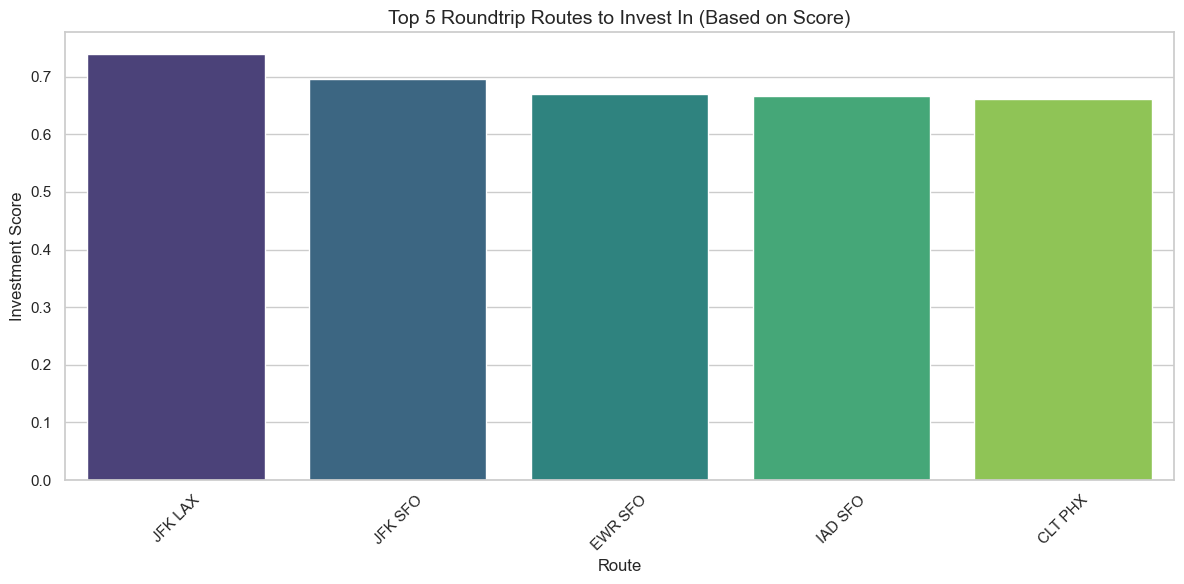

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set a clean style
sns.set(style="whitegrid")

# Ensure route column exists
investment_recommendations = investment_recommendations.copy()
investment_recommendations['route'] = investment_recommendations.index

# Sort by score
investment_recommendations = investment_recommendations.sort_values('score', ascending=False)

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=investment_recommendations,
    x='route', y='score',
    hue='route',        # <-- Assign hue to x variable
    legend=False,       # <-- Hide legend since each bar is unique
    palette='viridis'
)

# Customize chart
plt.title('Top 5 Roundtrip Routes to Invest In (Based on Score)', fontsize=14)
plt.xlabel('Route', fontsize=12)
plt.ylabel('Investment Score', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

## ✅ Recommendation

Focus your investment and resource strategy on these **top 5 routes**, as they offer:

- High profitability and efficiency
- Strong customer experience (low delays, more early arrivals)
- Strategic value in terms of network and frequency

Consider these routes for additional aircraft allocation, pricing experiments, or targeted promotions.

<!--
## Question Explanation

The airline company plans to launch 5 new roundtrip routes in the US domestic market. For each route, a new airplane must be purchased upfront at a cost of $90 million.

The key business question is:  
**How many roundtrip flights does it take for each route to generate enough profit to cover the initial airplane purchase cost?**

This breakeven calculation involves:  
- Determining the average profit per roundtrip flight for each route  
- Dividing the $90 million upfront cost by this average profit to find the number of flights needed to break even  

Understanding the breakeven point is crucial because it informs investment decisions, helps prioritize routes based on financial viability, and aligns with the company’s brand promise of punctuality and profitability.

-->



## 4.Question Explanation

The airline company plans to launch 5 new roundtrip routes in the US domestic market. For each route, a new airplane must be purchased upfront at a cost of $90 million.

The key business question is:  
**How many roundtrip flights does it take for each route to generate enough profit to cover the initial airplane purchase cost?**

This breakeven calculation involves:  
- Determining the average profit per roundtrip flight for each route  
- Dividing the $90 million upfront cost by this average profit to find the number of flights needed to break even  

Understanding the breakeven point is crucial because it informs investment decisions, helps prioritize routes based on financial viability, and aligns with the company’s brand promise of punctuality and profitability.


Breakeven Summary for Top 5 Recommended Routes:



C:\Users\uma shanker\AppData\Local\Temp\ipykernel_9380\1988358104.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


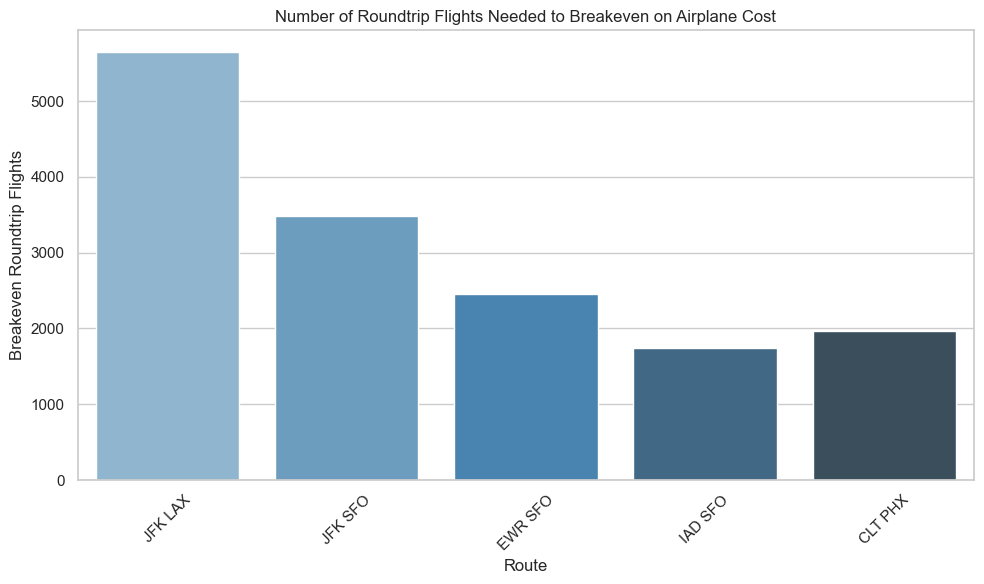

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'investment_recommendations' is your DataFrame of top 5 routes

# Step 1: Upfront airplane cost
upfront_cost = 90000000  # $90 million

# Step 2: Calculate profit per roundtrip flight
investment_recommendations['profit_per_roundtrip'] = (
    investment_recommendations['profit'] / investment_recommendations['roundtrip_count']
)

# Step 3: Calculate breakeven roundtrip flights needed (rounded up)
investment_recommendations['breakeven_roundtrips'] = np.ceil(
    upfront_cost / investment_recommendations['profit_per_roundtrip']
)

# Step 4: Print summary table
summary_columns = [
    'profit', 'roundtrip_count', 'profit_per_roundtrip', 'breakeven_roundtrips',
    'total_revenue', 'profit_margin', 'occupancy_avg', 'delay_dep', 'early_arr', 'score'
]

breakeven_summary = investment_recommendations[summary_columns]

print("Breakeven Summary for Top 5 Recommended Routes:\n")
breakeven_summary

# Step 5: Visualization - Barplot of Breakeven Flights by Route
plt.figure(figsize=(10,6))
sns.barplot(
    x=investment_recommendations.index, 
    y='breakeven_roundtrips', 
    data=investment_recommendations, 
    palette='Blues_d'
)
plt.title('Number of Roundtrip Flights Needed to Breakeven on Airplane Cost')
plt.xlabel('Route')
plt.ylabel('Breakeven Roundtrip Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Key Performance Indicators (KPIs) to Track for Route Success

To effectively measure the performance and success of the recommended round trip routes, the following KPIs are suggested for ongoing monitoring:

- **Profit**: Absolute profitability of each route, reflecting overall financial performance.
- **Profit Margin**: Profit relative to total revenue, indicating efficiency and cost control.
- **Total Revenue**: Total income generated from ticket sales and ancillary services.
- **Occupancy Average**: Average seat occupancy rate, a critical measure of route demand and capacity utilization.
- **Roundtrip Count**: Number of round trip flights, showing route frequency and market activity.
- **Departure Delay (delay_dep)**: Average delay in departure times, impacting punctuality and customer satisfaction.
- **Early Arrivals (early_arr)**: Percentage of flights arriving earlier than scheduled, enhancing customer experience.

Tracking these KPIs will help ensure alignment with the company’s motto **“On time, for you”**, emphasizing punctuality while maximizing profitability and operational efficiency.


Index(['docking_cost_a', 'docking_cost_b', 'roundtrip_start',
       'roundtrip_return', 'passengers', 'itin_fare', 'itin_fare_avg',
       'avg_occupancy_rate', 'occupancy_avg', 'roundtrip_count',
       'ticket_revenue', 'baggage_revenue', 'total_revenue', 'distance',
       'fomc&dio', 'roundtrip_start_airport_type',
       'roundtrip_return_airport_type', 'docking_cost_total', 'delay_dep',
       'early_arr', 'maintance', 'profit', 'profit_margin', 'score'],
      dtype='object')
KPI Summary for Top 5 Recommended Routes:

               profit  profit_margin  total_revenue  occupancy_avg  \
Routes                                                               
JFK LAX  5.031571e+07          41.85   1.202397e+08     130.014465   
JFK SFO  4.815300e+07          53.02   9.082181e+07     129.970714   
EWR SFO  4.449946e+07          61.06   7.288051e+07     129.981023   
IAD SFO  3.836395e+07          69.84   5.492881e+07     128.281122   
CLT PHX  3.258085e+07          68.32   4.768728e

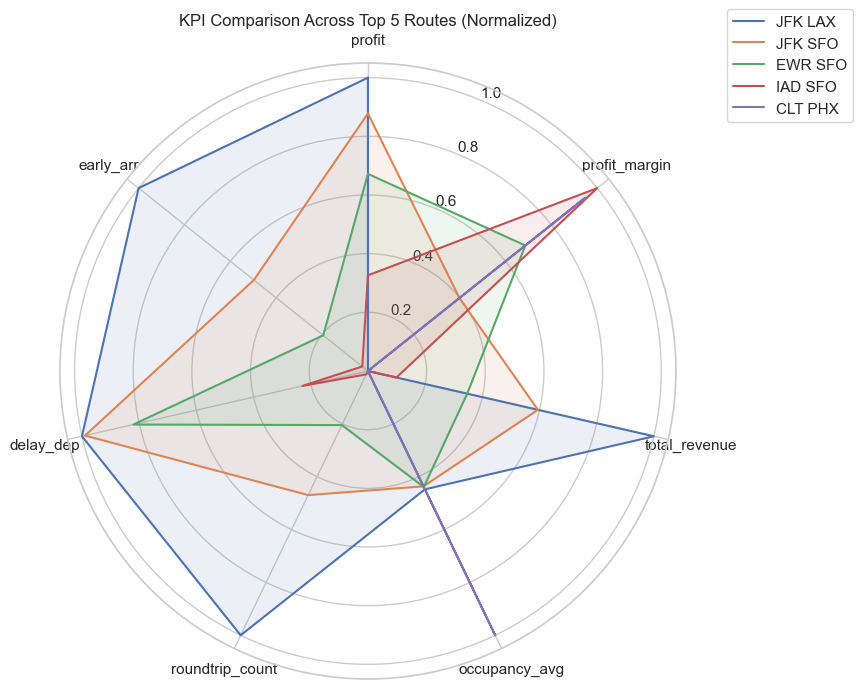

In [108]:
# Check column names
print(Final.columns)

# Correct column names (example)
kpi_cols = [
    'profit', 'profit_margin', 'total_revenue', 'occupancy_avg', 'roundtrip_count',
    'delay_dep', 'early_arr'
    # Removed 'maintance' and 'docking_cost_total' since missing
]

top_routes = investment_recommendations.index

kpi_summary = Final.loc[top_routes, kpi_cols]

print("KPI Summary for Top 5 Recommended Routes:\n")
print(kpi_summary)

# Normalize for radar plot
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np

scaler = MinMaxScaler()
kpi_scaled = scaler.fit_transform(kpi_summary.fillna(0))
kpi_scaled_df = pd.DataFrame(kpi_scaled, columns=kpi_cols, index=kpi_summary.index)

labels = np.array(kpi_cols)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, row in kpi_scaled_df.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=idx)
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title('KPI Comparison Across Top 5 Routes (Normalized)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


## Relationship Between KPIs and Top 5 Recommended Routes

The selection of the top 5 round trip routes was based on a balanced evaluation of these KPIs, highlighting how each metric contributes to overall route success:

- **Profit and Profit Margin:**  
  These two financial KPIs were weighted heavily in the recommendation, ensuring the routes chosen are not only generating high absolute profits but also maintaining strong profitability relative to their revenue. For example, routes like **JFK–LAX** and **IAD–SFO** exhibited both high profits and margins, indicating efficient operations and strong demand.

- **Occupancy Average:**  
  High occupancy rates indicate effective capacity utilization, which directly supports revenue and profit growth. The top 5 routes consistently showed occupancy levels above the dataset average, confirming robust passenger demand.

- **Roundtrip Count:**  
  The frequency of flights on each route impacts revenue potential and market presence. Routes with more roundtrips provide greater service availability, contributing to higher total revenues as seen in the top performers.

- **Departure Delay and Early Arrival:**  
  Since punctuality is a core brand value, routes with lower departure delays and higher early arrival rates were favored. These operational KPIs enhance customer satisfaction and brand reputation, directly aligning with the motto **“On time, for you.”**

By continuously monitoring these KPIs, the airline can maintain a balanced focus on profitability, operational efficiency, and customer experience, ensuring sustained success on these key routes.
